In [ ]:
# Gerekli kütüphaneleri içe aktarma
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik ayarları
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", palette="Set2")

# Türkçe karakter desteği için
plt.rcParams["axes.unicode_minus"] = False

print( "Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


In [ ]:
df= pd.read_csv("/content/ogrenci_uygulama_veri_seti.csv")
print("Veri seti okundu.")

Veri seti okundu.


In [ ]:
#Veri Setinin ilk 5 satırına bakmak
print(f'\n{"=" * 40}\n')
print("Veri setinin ilk 5 satırı")
print(f'\n{"=" * 40}')
df.head()




Veri setinin ilk 5 satırı



,musteri_id,yas,cinsiyet,sehir,egitim_duzeyi,urun_kategorisi,siparis_tutari_tl,siparis_adedi,memnuniyet_puani,iade_durumu
0,O0001,38,Erkek,Ankara,Ön Lisans,Kitap,378.39,5,5,Hayır
1,O0002,39,Kadın,Bursa,Lisans,Kitap,310.43,4,5,Hayır
2,O0003,38,Kadın,İstanbul,Lise,Giyim,1194.27,6,3,Evet
3,O0004,33,Kadın,Ankara,Yüksek Lisans,Ev & Yaşam,586.97,5,4,Hayır
4,O0005,29,Erkek,Ankara,Lise,Ev & Yaşam,111.80,3,5,Hayır


In [ ]:
# veri setinin son 5 satırına bakmak
print(f'\n{"=" * 40}\n')
print("Veri setinin son 5 satırı")
print(f'\n{"=" * 40}')
df.tail()



Veri setinin son 5 satırı



,musteri_id,yas,cinsiyet,sehir,egitim_duzeyi,urun_kategorisi,siparis_tutari_tl,siparis_adedi,memnuniyet_puani,iade_durumu
495,O0496,34,Erkek,Antalya,Yüksek Lisans,Spor,270.79,3,4,Hayır
496,O0497,37,Kadın,İzmir,Lisans,Elektronik,499.56,3,5,Hayır
497,O0498,37,Erkek,Antalya,Lisans,Giyim,402.71,2,4,Evet
498,O0499,32,Kadın,İzmir,Lisans,Giyim,703.99,3,5,Evet
499,O0500,40,Kadın,İstanbul,Lise,Ev & Yaşam,190.55,1,4,Hayır


In [ ]:
#Toplam satır ve sütun sayısı
print(f"DataFrame'in boyutları (satır sayısı, sütun sayısı): {df.shape}")

DataFrame'in boyutları (satır sayısı, sütun sayısı): (500, 10)


In [ ]:
# veri setinin genel yapısı
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   musteri_id         500 non-null    object 
 1   yas                500 non-null    int64  
 2   cinsiyet           500 non-null    object 
 3   sehir              500 non-null    object 
 4   egitim_duzeyi      500 non-null    object 
 5   urun_kategorisi    500 non-null    object 
 6   siparis_tutari_tl  500 non-null    float64
 7   siparis_adedi      500 non-null    int64  
 8   memnuniyet_puani   500 non-null    int64  
 9   iade_durumu        500 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 39.2+ KB


In [ ]:
# Veri tiplerini belirliyoruz
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
object_cols = df.select_dtypes(include='object').columns.tolist()
print(f'\n{"=" * 120}')
print("Sayısal Sütunlar:", numerical_cols)
print(f'\n{"=" * 120}')
print("Kategorik (Object) Sütunlar:", object_cols)
print(f'\n{"=" * 120}')


Sayısal Sütunlar: ['yas', 'siparis_tutari_tl', 'siparis_adedi', 'memnuniyet_puani']

Kategorik (Object) Sütunlar: ['musteri_id', 'cinsiyet', 'sehir', 'egitim_duzeyi', 'urun_kategorisi', 'iade_durumu']



In [ ]:
# Eksik değer (NaN/Null) kontrolü
df.isnull().values.any()

np.False_

In [ ]:
# Sayısal değişkenler için hesaplamalar
print(f'\n{"=" * 55}')
print(f'  Sayısal Değişkenler İçin Tanımlayıcı İstatistikler')
print(f'{"=" * 55}')

print(df[numerical_cols].describe())


  Sayısal Değişkenler İçin Tanımlayıcı İstatistikler
             yas  siparis_tutari_tl  siparis_adedi  memnuniyet_puani
count  500.00000         500.000000     500.000000        500.000000
mean    32.10200         710.874440       3.438000          3.650000
std     10.12782         782.737161       1.821206          1.087136
min     18.00000          11.270000       1.000000          1.000000
25%     24.00000         191.875000       2.000000          3.000000
50%     32.00000         475.765000       3.000000          4.000000
75%     39.00000        1022.677500       5.000000          4.000000
max     65.00000        6953.390000       9.000000          5.000000


In [ ]:
# Kategorik değişkenler için benzersiz (unique) değerleri bulma
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols = categorical_cols[1:]
print(categorical_cols)
print("=" * 70)
for col in categorical_cols:
    print(f"{col} için benzersiz değerler: {df[col].unique()}\n")
    print('=' * 70)

['cinsiyet', 'sehir', 'egitim_duzeyi', 'urun_kategorisi', 'iade_durumu']
cinsiyet için benzersiz değerler: ['Erkek' 'Kadın']

sehir için benzersiz değerler: ['Ankara' 'Bursa' 'İstanbul' 'İzmir' 'Antalya']

egitim_duzeyi için benzersiz değerler: ['Ön Lisans' 'Lisans' 'Lise' 'Yüksek Lisans']

urun_kategorisi için benzersiz değerler: ['Kitap' 'Giyim' 'Ev & Yaşam' 'Spor' 'Elektronik']

iade_durumu için benzersiz değerler: ['Hayır' 'Evet']



In [ ]:
# Tüm kategorik değişkenlerin frekans tablosu
kategorik_degiskenler = ['cinsiyet', 'sehir', 'egitim_duzeyi', 'urun_kategorisi', 'iade_durumu']

for deg in kategorik_degiskenler:
    print(f'\n{"=" * 40}')
    print(f'  {deg.upper()}')
    print(f'{"=" * 40}')
    frekans = df[deg].value_counts()
    yuzde = df[deg].value_counts(normalize=True).map('{:.1%}'.format)
    tablo = pd.DataFrame({'Frekans': frekans, 'Yüzde': yuzde})
    print(tablo)
    print()



  CINSIYET
          Frekans  Yüzde
cinsiyet                
Kadın         267  53.4%
Erkek         233  46.6%


  SEHIR
          Frekans  Yüzde
sehir                   
İstanbul      185  37.0%
Ankara         86  17.2%
Bursa          82  16.4%
Antalya        77  15.4%
İzmir          70  14.0%


  EGITIM_DUZEYI
               Frekans  Yüzde
egitim_duzeyi                
Lisans             170  34.0%
Ön Lisans          130  26.0%
Lise               112  22.4%
Yüksek Lisans       88  17.6%


  URUN_KATEGORISI
                 Frekans  Yüzde
urun_kategorisi                
Giyim                128  25.6%
Elektronik           121  24.2%
Ev & Yaşam            94  18.8%
Spor                  83  16.6%
Kitap                 74  14.8%


  IADE_DURUMU
             Frekans  Yüzde
iade_durumu                
Hayır            420  84.0%
Evet              80  16.0%



In [ ]:
# Şehirlere göre ortalama sipariş tutarı ve memnuniyet puanı
print(f'\n{"=" * 63}')
print(f'  Şehirlere Göre Ortalama Sipariş Tutarı ve Memnuniyet Puanı')
print(f'{"=" * 63}')
sehir_analizi = df.groupby('sehir')[['siparis_tutari_tl', 'memnuniyet_puani']].mean()
print(sehir_analizi)


  Şehirlere Göre Ortalama Sipariş Tutarı ve Memnuniyet Puanı
          siparis_tutari_tl  memnuniyet_puani
sehir                                        
Ankara           679.270116          3.674419
Antalya          748.887143          3.571429
Bursa            785.825000          3.780488
İstanbul         762.410757          3.589189
İzmir            483.886286          3.714286


In [ ]:
# Ürün kategorilerine göre toplam sipariş adadei karşılaştırma
print(f'\n{"=" * 60}')
print(f'  Ürün Kategorilerine Göre Toplam Sipariş Adedi')
print(f'{"=" * 60}')
urun_kategori_siparis = df.groupby('urun_kategorisi')['siparis_adedi'].sum().sort_values(ascending=False)
print(urun_kategori_siparis)


  Ürün Kategorilerine Göre Toplam Sipariş Adedi
urun_kategorisi
Elektronik    439
Giyim         439
Ev & Yaşam    344
Spor          257
Kitap         240
Name: siparis_adedi, dtype: int64


In [ ]:
# Cinsiyet ve eğitim düzeyine göre iade oranı için çapraz tablo oluşturma
print(f'\n{"=" * 60}')
print(f'  Cinsiyet ve Eğitim Düzeyine Göre İade Durumu Çapraz Tablosu')
print(f'{"=" * 60}')

crosstab_df = pd.crosstab(index=[df['cinsiyet'], df['egitim_duzeyi']], columns=df['iade_durumu'])
print(crosstab_df)

print(f'\n{"=" * 60}')
print(f'  Cinsiyet ve Eğitim Düzeyine Göre İade Oranları')
print(f'{"=" * 60}')

crosstab_percent = pd.crosstab(index=[df['cinsiyet'], df['egitim_duzeyi']], columns=df['iade_durumu'], normalize='index')
crosstab_percent['Evet'] = crosstab_percent['Evet'].map('{:.2%}'.format)
crosstab_percent['Hayır'] = crosstab_percent['Hayır'].map('{:.2%}'.format)
print(crosstab_percent)


  Cinsiyet ve Eğitim Düzeyine Göre İade Durumu Çapraz Tablosu
iade_durumu             Evet  Hayır
cinsiyet egitim_duzeyi             
Erkek    Lisans           10     53
         Lise             12     48
         Yüksek Lisans     8     32
         Ön Lisans         6     64
Kadın    Lisans           17     90
         Lise             10     42
         Yüksek Lisans    10     38
         Ön Lisans         7     53

  Cinsiyet ve Eğitim Düzeyine Göre İade Oranları
iade_durumu               Evet   Hayır
cinsiyet egitim_duzeyi                
Erkek    Lisans         15.87%  84.13%
         Lise           20.00%  80.00%
         Yüksek Lisans  20.00%  80.00%
         Ön Lisans       8.57%  91.43%
Kadın    Lisans         15.89%  84.11%
         Lise           19.23%  80.77%
         Yüksek Lisans  20.83%  79.17%
         Ön Lisans      11.67%  88.33%


In [ ]:
# Müşteri yaşı ile spariş tutarı arasındaki istatistiksel olarak korelasyon olması durumu:
correlation = df['yas'].corr(df['siparis_tutari_tl'])
print(f"Müşteri yaşı ile sipariş tutarı arasındaki korelasyon: {correlation:.2f}")

if correlation > 0.5:
    print("\n→ Yaş ile sipariş tutarı arasında güçlü pozitif bir ilişki var.")
elif correlation < -0.5:
    print("\n→ Yaş ile sipariş tutarı arasında güçlü negatif bir ilişki var.")
elif correlation > 0.2 or correlation < -0.2:
    print("\n→ Yaş ile sipariş tutarı arasında orta düzeyde bir ilişki var.")
else:
    print("\n→ Yaş ile sipariş tutarı arasında zayıf veya hiç ilişki yok.")

Müşteri yaşı ile sipariş tutarı arasındaki korelasyon: 0.05

→ Yaş ile sipariş tutarı arasında zayıf veya hiç ilişki yok.


In [ ]:
#Ürünleri görme:
print(urun_kategori_siparis)

urun_kategorisi
Elektronik    439
Giyim         439
Ev & Yaşam    344
Spor          257
Kitap         240
Name: siparis_adedi, dtype: int64


/tmp/ipykernel_152/1447725550.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=urun_kategori_siparis.index, y=urun_kategori_siparis.values, palette='viridis')


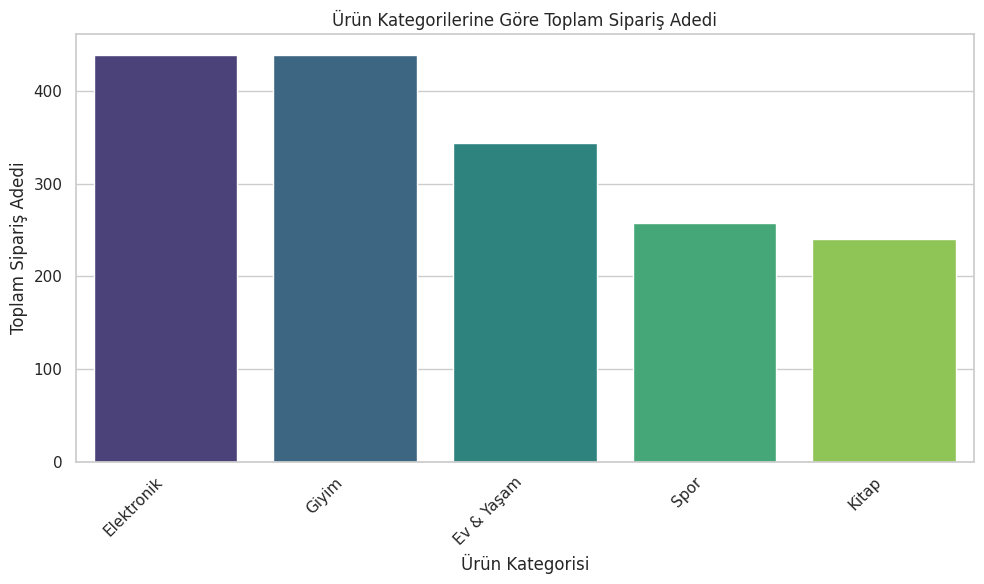

In [ ]:
# Ürün kategorilerini bar chart ile gösterme:
plt.figure(figsize=(10, 6))
sns.barplot(x=urun_kategori_siparis.index, y=urun_kategori_siparis.values, palette='viridis')
plt.title('Ürün Kategorilerine Göre Toplam Sipariş Adedi')
plt.xlabel('Ürün Kategorisi')
plt.ylabel('Toplam Sipariş Adedi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Yorum:**
Öne Çıkan Kategoriler: Elektronik ve Giyim kategorileri, en yüksek spariş adedine (her ikisi de 439 spariş) sahip olup , şirketin satış hacmini önemli bir kısmını karşılamaktadır.

**Şirket İçin Çıkarımlar:**

Şirket, Elektronik ve Giyim kategorilerindeki güçlü pozisyonunu korumak ve geliştirmek için stratejiler geliştirmelidir. Bu kategorilerdeki trendleri takip etmek, stok yönetimini optimize etmek ve pazarlama faaliyetlerini bu alanlara odaklamak faydalı olacaktır.

Ev & Yaşam ve Spor gibi orta düzey kategorilerde çapraz satış veya yukarı satış stratejileri ile sipariş adedini artırma potansiyeli değerlendirilebilir.

Kitap kategorisinin düşük performansı, bu alandaki ürün yelpazesini, fiyatlandırmayı veya pazarlama stratejilerini gözden geçirme ihtiyacını işaret edebilir. Belki de bu kategoride farklı müşteri segmentlerine hitap eden niş ürünler veya özel kampanyalar düşünülebilir.


In [ ]:
# Şehirleri görme:
print(sehir_analizi)

          siparis_tutari_tl  memnuniyet_puani
sehir                                        
Ankara           679.270116          3.674419
Antalya          748.887143          3.571429
Bursa            785.825000          3.780488
İstanbul         762.410757          3.589189
İzmir            483.886286          3.714286


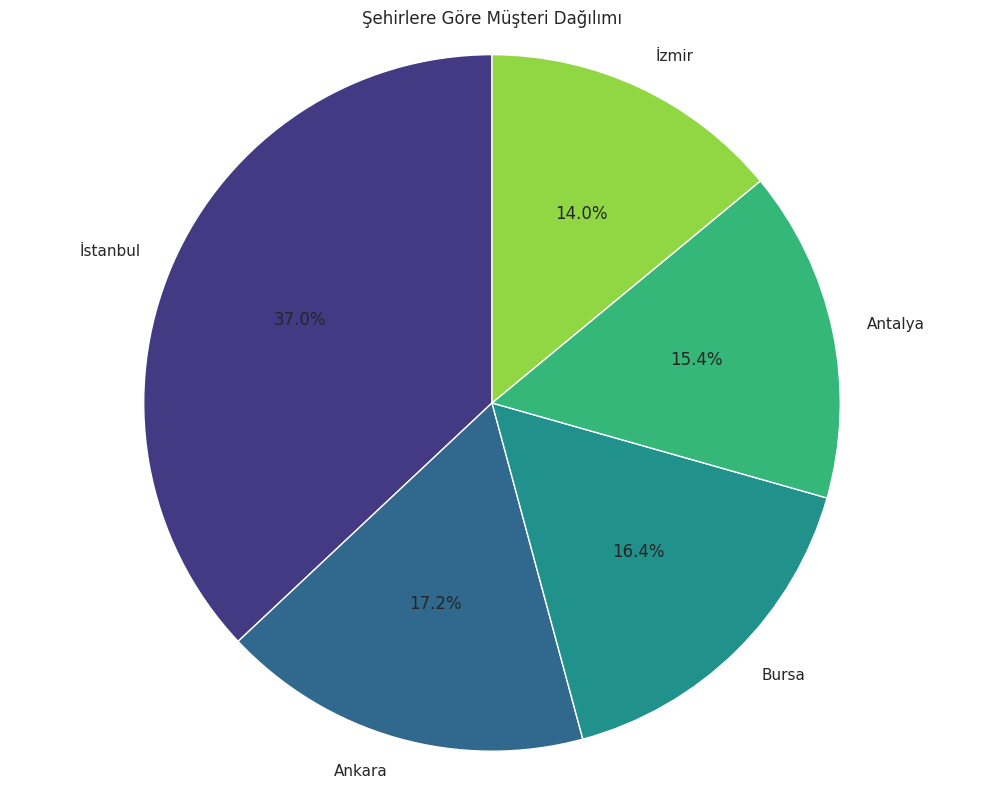

In [ ]:
# Şehire göre müşteri dağılımı (Pie Chart):
plt.figure(figsize=(10, 8))

sehir_sayilari = df['sehir'].value_counts()

plt.pie(sehir_sayilari, labels=sehir_sayilari.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(sehir_sayilari)))
plt.title('Şehirlere Göre Müşteri Dağılımı')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

**Yorum:**
En büyük müşteri tabanı İstanbul'dur. %37.0 ile açık ara en büyük müşteri tabanına sahiptir. Bu, şirketin İstanbul pazarında çok güçlü olduğunu ve bu şehrin genel müşteri portföyünde kritik bir rol oynadığını göstermektedir.

**Şirket İçin Çıkarımlar:**

İstanbul Odaklanması: Şirket, İstanbul'daki mevcut güçlü konumunu korumak ve geliştirmek için özel pazarlama ve operasyonel stratejiler uygulamaya devam etmelidir. Bu pazardaki rekabet avantajını sürdürmek önemlidir.

Büyüme Potansiyeli: Ankara, Bursa ve Antalya gibi şehirler, İstanbul'a kıyasla daha küçük olsa da önemli müşteri potansiyeline sahiptir. Bu şehirlerdeki pazar payını artırmak için bölgesel kampanyalar veya yerel taleplere yönelik ürünler sunulabilir.

İzmir'de Fırsatlar/Zorluklar: İzmir'deki düşük müşteri payı, bu şehirde yeni müşteri kazanımı için fırsatlar veya mevcut stratejilerde eksiklikler olduğunu gösterebilir. İzmir için daha agresif pazarlama, yerel etkinlikler veya bölgeye özel indirimler düşünülebilir. Ancak, İzmir'deki ortalama sipariş tutarının diğer şehirlere göre daha düşük olduğu göz önüne alındığında, bu pazardaki yatırım getirisi dikkatli değerlendirilmelidir.

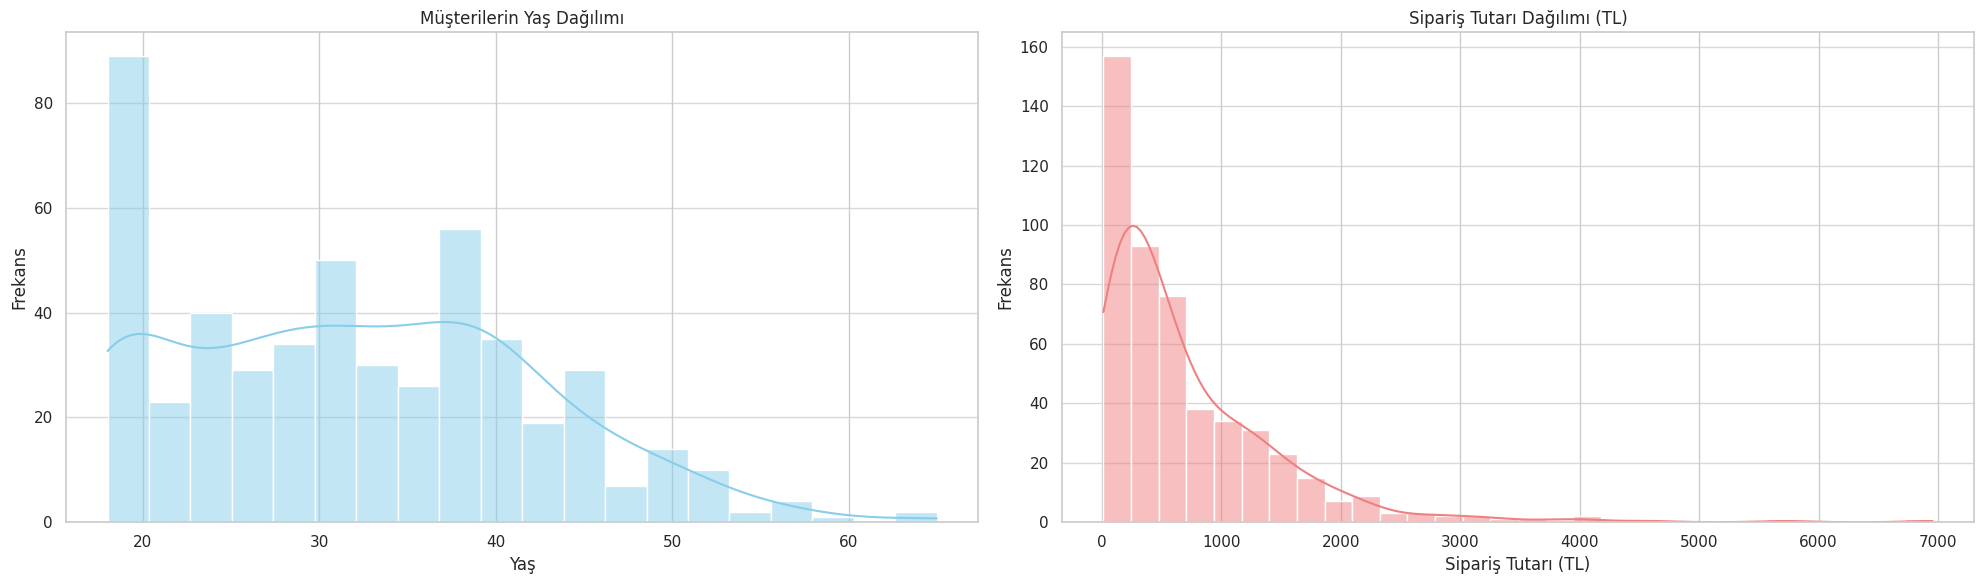

In [ ]:
#Müşteri yaş dağılımı ile spariş tutarı arasındaki ilişki:
fig, axes = plt.subplots(1, 2, figsize=(20, 6)) # 1 satır, 2 sütun ile iki alt grafik oluştur

# Birinci alt grafik: Müşteri yaş dağılımı
sns.histplot(df['yas'], kde=True, bins=20, color='skyblue', ax=axes[0])
axes[0].set_title('Müşterilerin Yaş Dağılımı')
axes[0].set_xlabel('Yaş')
axes[0].set_ylabel('Frekans')
axes[0].grid(axis='y', alpha=0.75)

# İkinci alt grafik: Sipariş tutarı dağılımı
sns.histplot(df['siparis_tutari_tl'], kde=True, bins=30, color='lightcoral', ax=axes[1])
axes[1].set_title('Sipariş Tutarı Dağılımı (TL)')
axes[1].set_xlabel('Sipariş Tutarı (TL)')
axes[1].set_ylabel('Frekans')
axes[1].grid(axis='y', alpha=0.75)

plt.tight_layout() # Grafikler arasında boşluk bırak
plt.show()

**1.Müşterilerin Yaş Dağılımı Grafiği:**
**Genel Dağılım:** Genç ve orta yaş gruplarındaki müşterilerin ağırlıklı olduğu görülmektedir. Dağılımın en yoğun olduğu yaş aralıkları genellikle 20'li ve 30'lu yaşlardır. Daha ileri yaş gruplarına doğru müşteri sayısında bir azalma eğilimi vardır.

**Çıkarım:** Şirketin hedef kitlesinin ağırlıklı olarak genç ve orta yaşlı bireylerden oluştuğunu anlayabiliriz. Pazarlama stratejileri ve ürün geliştirme süreçlerinde bu yaş gruplarının tercihleri ve ihtiyaçları ön planda tutulmalıdır.

**2. Sipariş Tutarı Dağılımı Grafiği:**

**Genel Dağılım:** Sipariş tutarlarının büyük bir kısmının düşük ve orta seviyelerde yoğunlaştığı gözlemlenmektedir. Dağılım sağa çarpık (pozitif çarpık) bir yapıya sahiptir, yani çoğu sipariş nispeten düşük tutarlarda iken, az sayıda çok yüksek tutarlı siparişler de bulunmaktadır.

**Aykırı Değerler:** Grafiğin sağ tarafında, frekansın çok düşük olduğu ancak tutarların çok yüksek olduğu bölgeler mevcuttur. Bu, daha önce incelediğimiz aykırı değerlerin (outlier) varlığını görsel olarak da doğrulamaktadır. Yani, az sayıda müşteri çok yüksek tutarlı alışverişler yapmaktadır.

**Çıkarım:** Şirketin gelirlerinin büyük bir kısmı sık ve küçük/orta ölçekli siparişlerden gelmekle birlikte, yüksek harcama yapan niş bir müşteri kitlesinin de olduğu anlaşılmaktadır. Bu yüksek harcama yapan müşterilerin özelliklerinin analiz edilmesi, benzer müşteri segmentlerine ulaşmak veya mevcut yüksek değerli müşterileri elde tutmak için stratejiler geliştirilmesine yardımcı olabilir.

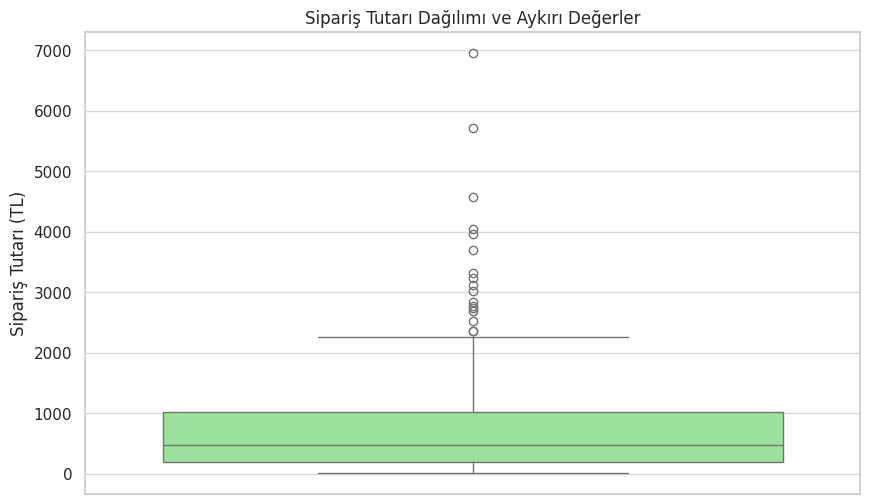

In [ ]:
# Spariş tutarındaki aykırı değerleri bulma:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['siparis_tutari_tl'], color='lightgreen')
plt.title('Sipariş Tutarı Dağılımı ve Aykırı Değerler')
plt.ylabel('Sipariş Tutarı (TL)')
plt.grid(axis='y', alpha=0.75)
plt.show()

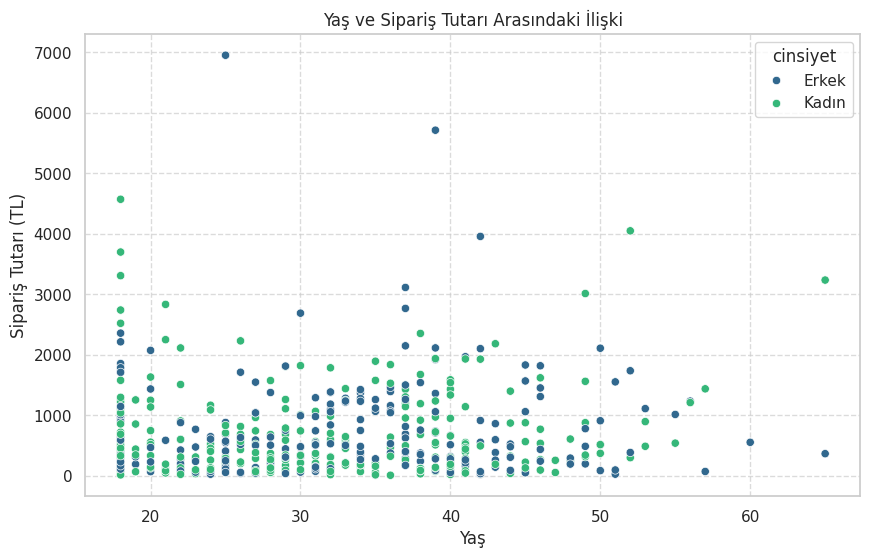

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='yas', y='siparis_tutari_tl', data=df, hue='cinsiyet', palette='viridis')
plt.title('Yaş ve Sipariş Tutarı Arasındaki İlişki')
plt.xlabel('Yaş')
plt.ylabel('Sipariş Tutarı (TL)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

***Genel Değerlendirme:***

***Veri Kalitesi ve Kapsamı:*** 500 müşteriye ait sipariş ve memnuniyet verileri mevcut olup, herhangi bir eksik değer bulunmamaktadır. Bu durum, analizin güvenilirliği açısından olumlu bir göstergedir.

***Müşteri Dağılımı:*** Kadın müşteriler (53.4%) erkeklere göre biraz daha fazladır. Müşteri tabanının büyük bir kısmı İstanbul'da (37%) yoğunlaşmıştır. Eğitim düzeyleri açısından Lisans (34%) mezunları en büyük grubu oluşturmaktadır.

***Ürün Tercihleri:*** Giyim ve Elektronik kategorileri toplam sipariş adedi açısından öne çıkmaktadır. Bu iki kategori, şirketin satış hacminin önemli bir kısmını oluşturmaktadır.

***Sipariş Tutarı ve Yaş İlişkisi:*** Yaş ile sipariş tutarı arasında zayıf bir korelasyon (0.05) gözlemlenmiştir, bu da sipariş tutarının yaştan bağımsız olarak farklılık gösterdiğini işaret etmektedir. Sipariş tutarı dağılımında yüksek miktarlı aykırı değerler (outlier) bulunmaktadır, bu da yüksek harcama yapan niş bir müşteri kitlesinin varlığını göstermektedir.

***Memnuniyet ve İade Oranları:*** Ortalama memnuniyet puanı 3.65'tir. Genel iade oranı %16 civarındadır. İade oranları cinsiyet ve eğitim düzeyine göre farklılık göstermektedir; örneğin, Yüksek Lisans mezunu kadınların iade oranı diğer gruplara göre biraz daha yüksektir (%20.83).

***Şirket Gelirlerini Artırmak İçin Odaklanılması Gereken Alanlar:***

***Ürün Kategorisi:***

***Odaklanılması Gerekenler:*** Elektronik ve Giyim kategorileri, en yüksek sipariş adetlerine sahip olduğu için mevcut potansiyellerini sürdürmek ve artırmak adına pazarlama ve kampanya çalışmalarının bu kategoriler üzerinde yoğunlaştırılması gerekmektedir. Bu ürünlerdeki trendleri yakından takip ederek stok yönetimi ve yeni ürün tedariki optimize edilmelidir.

***Geliştirilebilecekler:*** Diğer kategoriler (Ev & Yaşam, Spor, Kitap) için çapraz satış ve yukarı satış stratejileri geliştirilebilir. Örneğin, Giyim kategorisinden alışveriş yapanlara Ev & Yaşam ürünleri, Elektronik ürün alanlara aksesuar önerileri sunulabilir.

***Şehir:***

***Odaklanılması Gerekenler:*** İstanbul en büyük müşteri tabanına sahip olduğu için bu şehirdeki marka bilinirliği ve pazar payı daha da artırılmalıdır. Bursa'daki müşterilerin ortalama sipariş tutarı en yüksek olduğundan, bu şehirdeki yüksek harcama eğilimini anlamak ve bu durumu diğer şehirlere yaymak için özel çalışmalar yapılabilir.

***Geliştirilebilecekler:*** İzmir'in ortalama sipariş tutarı en düşük olduğu için, bu şehirde özel indirimler, ücretsiz kargo kampanyaları veya yerel etkinliklerle müşteri ilgisi ve harcaması artırılmaya çalışılabilir.

***Yaş Grubu:***

Yaş ile sipariş tutarı arasında güçlü bir ilişki olmaması nedeniyle belirli bir yaş grubuna odaklanmak yerine, daha çok yüksek sipariş tutarı olan müşterilerin davranışları incelenmelidir. Aykırı değerleri oluşturan bu müşterilerin demografik ve davranışsal özellikleri analiz edilerek benzer müşteri segmentleri hedeflenebilir.

***Memnuniyet Oranlarını Artırmak veya İade Oranlarını Düşürmek İçin Veriye Dayalı Aksiyon Önerileri:***

***Yüksek İadeli Segmentlere Yönelik İyileştirmeler (Kadın, Yüksek Lisans ve Lise Mezunları):***

***Aksiyon:*** Özellikle Yüksek Lisans ve Lise mezunu kadın müşterilerin iade oranlarının yüksek olduğu gözlemlenmiştir. Bu gruplardan detaylı geri bildirim toplanarak (anketler, odak grupları) iade nedenleri anlaşılmalıdır. Ürün açıklamalarının, görsellerinin ve beden tablolarının bu segmentlerin beklentilerine göre iyileştirilmesi, ürünleri daha doğru tanıtmaları ve yanlış siparişleri azaltmaları hedeflenmelidir.

***Hedef:*** Bu segmentlerdeki iade oranlarını %15'in altına çekmek.
Düşük Memnuniyetli Şehirlerde Hizmet Kalitesini Artırma (Antalya ve İstanbul):

***Aksiyon:*** Antalya ve İstanbul gibi ortalama memnuniyet puanı diğer şehirlere göre düşük olan bölgelerde müşteri hizmetleri kalitesinin artırılmasına odaklanılmalıdır. Teslimat sürelerinin iyileştirilmesi, iade/değişim süreçlerinin hızlandırılması ve müşteri şikayetlerinin daha etkin yönetilmesi için yerel operasyonel süreçler gözden geçirilmelidir.

***Hedef:*** Bu şehirlerdeki ortalama memnuniyet puanını 4.0'a yükseltmek.

***Kilit Ürün Kategorilerinde Detaylı Ürün Sunumu (Elektronik ve Giyim):***

***Aksiyon:*** En çok sipariş edilen Elektronik ve Giyim kategorilerinde, ürün sayfaları daha detaylı bilgilerle zenginleştirilmelidir. Elektronik ürünler için teknik özelliklerin anlaşılır sunumu, Giyim ürünleri için farklı açılardan çekilmiş görseller, video gösterimleri ve detaylı beden tabloları eklenmelidir. Müşteri yorumlarının teşvik edilmesi ve şeffaf bir şekilde sergilenmesi, diğer müşterilerin doğru karar vermesine yardımcı olacaktır.

***Hedef:*** Bu kategorilerdeki iade oranlarını genel ortalamanın altına çekmek ve müşteri memnuniyetini artırmak.